# NLSY97 College Completion & Employment Analysis
**Stat 486 Course Project**

**Goals:**
1. Understand characteristics of students more/less likely to complete college
2. Estimate the effect of college completion on unemployment (`prop_Unemployed`)

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load & Clean Data

In [80]:
# Update path if needed
df = pd.read_csv('stat486_nlsy97_employment.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (7741, 33)
Columns: ['ID', 'sex', 'DOB', 'age97', 'compcoll_age25', 'race', 'father_educ_years', 'mother_educ_years', 'parinc', 'intact', 'sibsz', 'region_age17', 'urban_rural_age17', 'asvab_mv_pct', 'grades8th', 'hsprog', 'gpa', 'peers_aspiration_college', 'delinq', 'tchgood', 'schsafe', 'marstat_age17', 'res_children_age17', 'weeks_Unemployed', 'weeks_Out of labor force', 'weeks_Employed', 'weeks_Not working (unclear if unemployed or NILF)', 'weeks_Active military', 'prop_Unemployed', 'prop_Out of labor force', 'prop_Employed', 'prop_Not working (unclear if unemployed or NILF)', 'prop_Active military']


,ID,sex,DOB,age97,compcoll_age25,race,father_educ_years,mother_educ_years,parinc,intact,...,weeks_Unemployed,weeks_Out of labor force,weeks_Employed,weeks_Not working (unclear if unemployed or NILF),weeks_Active military,prop_Unemployed,prop_Out of labor force,prop_Employed,prop_Not working (unclear if unemployed or NILF),prop_Active military
0,1,F,1981-09-01,15,1,Non-Black / Non-Hispanic,16.0,8.0,137750.0,1.0,...,250.0,155.0,492.0,0.0,0.0,0.278707,0.172798,0.548495,0.0,0.0
1,2,M,1982-07-01,14,0,Hispanic,17.0,15.0,84000.0,NaN,...,1.0,0.0,853.0,0.0,0.0,0.001171,0.000000,0.998829,0.0,0.0
2,3,F,1983-09-01,13,0,Hispanic,NaN,12.0,81000.0,0.0,...,0.0,172.0,541.0,0.0,0.0,0.000000,0.241234,0.758766,0.0,0.0


In [82]:
# ── Summary statistics ──────────────────────────────────────────────────────
print('=== Missing values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\n=== College completion rate ===')
print(df['compcoll_age25'].value_counts())
print(f"Overall rate: {df['compcoll_age25'].mean():.3f}")

=== Missing values ===
father_educ_years                                    1477
mother_educ_years                                     539
parinc                                                557
intact                                                944
sibsz                                                 865
asvab_mv_pct                                         1460
grades8th                                              33
hsprog                                                 51
gpa                                                    43
peers_aspiration_college                               91
delinq                                                 11
tchgood                                                14
schsafe                                                16
marstat_age17                                          59
res_children_age17                                      1
weeks_Unemployed                                      315
weeks_Out of labor force                         

In [84]:
# ── Feature engineering ─────────────────────────────────────────────────────
df['asvab_q'] = pd.qcut(df['asvab_mv_pct'], q=4, labels=['Q1','Q2','Q3','Q4'])
df['inc_q']   = pd.qcut(df['parinc'],        q=4, labels=['Q1','Q2','Q3','Q4'])

# Ordered peer aspiration mapping
peer_order = {
    'Almost none (<10%)': 1, 'About 25%': 2,
    'About half (50%)':   3, 'About 75%': 4,
    'Almost all (>90%)':  5
}
df['peer_ord'] = df['peers_aspiration_college'].map(peer_order)

print('Feature engineering done.')
df[['asvab_q','inc_q','peer_ord']].head()

Feature engineering done.


,asvab_q,inc_q,peer_ord
0,Q2,Q4,4.0
1,Q3,Q4,4.0
2,Q2,Q4,3.0
3,Q2,Q1,5.0
4,NaN,Q3,4.0


---
## 2. Goal 1 — Who Completes College?

In [87]:
g = df.groupby('asvab_q')['compcoll_age25']
g.sum()

asvab_q
Q1     77
Q2    222
Q3    466
Q4    873
Name: compcoll_age25, dtype: int64

In [89]:
g = df.groupby('asvab_q')['compcoll_age25']
finalcount = 0
for name, group in g:
    finalcount += g.sum()

print(finalcount)
# for name, group in g:
#     print("Group:", name)
#     print(group.sum())
#     print()

asvab_q
Q1     308
Q2     888
Q3    1864
Q4    3492
Name: compcoll_age25, dtype: int64


In [91]:
g = df.groupby('gpa')['compcoll_age25']
fc = 0
for name, group in g:
    fc += group.sum()
print(fc)
# for name, group in g:
#     print("Group:", name)
#     print(group.sum() / 1638)
#     print()

1883


In [93]:
# ── Completion rates by demographic group ───────────────────────────────────
print('=== By sex ===')
print(df.groupby('sex')['compcoll_age25'].agg(['mean','count']).round(3))

print('\n=== By race ===')
print(df.groupby('race')['compcoll_age25'].agg(['mean','count']).round(3))

print('\n=== By intact family ===')
print(df.groupby('intact')['compcoll_age25'].agg(['mean','count']).round(3))

print('\n=== By GPA ===')

g = df.groupby('gpa')['compcoll_age25']
fc = 0
for name, group in g:
    fc += group.sum()
#print(fc)
print((df.groupby('gpa')['compcoll_age25'].sum()/fc).round(3))




print('\n=== By ASVAB quartile ===')
g = df.groupby('gpa')['compcoll_age25']
fcas = 0
for name, group in g:
    fcas += group.sum()
print((df.groupby('asvab_q')['compcoll_age25'].sum()/fcas).round(3))



print('\n=== By parental income quartile ===')
print(df.groupby('inc_q')['compcoll_age25'].mean().round(3))

print('\n=== By peer college aspiration ===')
print(df.groupby('peers_aspiration_college')['compcoll_age25'].mean().round(3))

=== By sex ===
      mean  count
sex              
F    0.284   3846
M    0.204   3895

=== By race ===
                            mean  count
race                                   
Black                      0.151   1967
Hispanic                   0.149   1537
Mixed Race (Non-Hispanic)  0.280     75
Non-Black / Non-Hispanic   0.322   4162

=== By intact family ===
         mean  count
intact              
0.0     0.153   3548
1.0     0.357   3249

=== By GPA ===
gpa
0.0    0.000
1.0    0.001
1.5    0.004
2.0    0.030
2.5    0.114
3.0    0.180
3.5    0.330
4.0    0.341
Name: compcoll_age25, dtype: float64

=== By ASVAB quartile ===
asvab_q
Q1    0.041
Q2    0.118
Q3    0.247
Q4    0.464
Name: compcoll_age25, dtype: float64

=== By parental income quartile ===
inc_q
Q1    0.095
Q2    0.192
Q3    0.268
Q4    0.442
Name: compcoll_age25, dtype: float64

=== By peer college aspiration ===
peers_aspiration_college
About 25%             0.098
About 75%             0.289
About half (50%)    

In [95]:
# ── Bivariate correlations with college completion ───────────────────────────
numeric_cols = [
    'father_educ_years','mother_educ_years','parinc',
    'asvab_mv_pct','grades8th','gpa','delinq',
    'tchgood','schsafe','sibsz','peer_ord'
]
corrs = {
    c: df[['compcoll_age25', c]].dropna().corr().iloc[0,1]
    for c in numeric_cols
}
corr_df = pd.Series(corrs, name='r').sort_values(key=abs, ascending=False)
print('Pearson r with compcoll_age25:')
print(corr_df.round(3))

Pearson r with compcoll_age25:
asvab_mv_pct         0.448
gpa                  0.410
grades8th            0.399
father_educ_years    0.326
mother_educ_years    0.301
parinc               0.286
peer_ord             0.193
delinq              -0.169
schsafe              0.133
sibsz               -0.130
tchgood              0.123
Name: r, dtype: float64


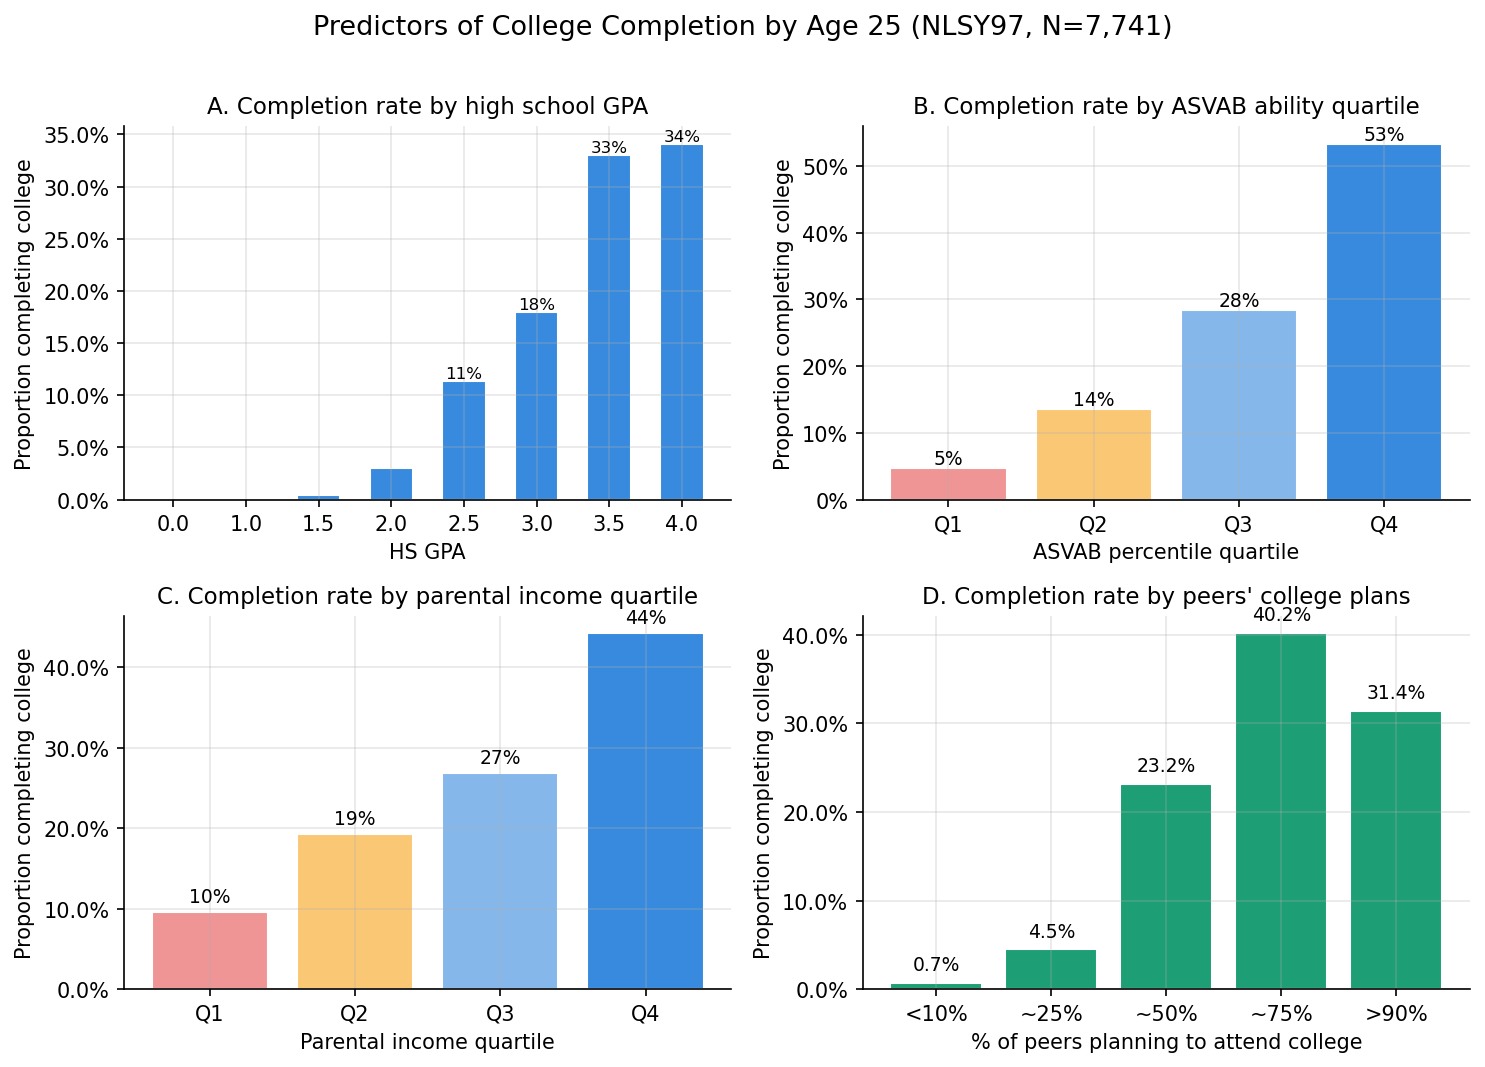

Figure 1 saved.


In [97]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Predictors of College Completion (4-panel)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Predictors of College Completion by Age 25 (NLSY97, N=7,741)', fontsize=13, y=1.01)

BLUE   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
GRAY   = '#888780'

# ── Panel A: Completion rate by HS GPA ──────────────────────────────────────
ax = axes[0, 0]
g = df.groupby('gpa')['compcoll_age25']
fc = 0
for name, group in g:
    fc += group.sum()
gpa_data = (df.groupby('gpa')['compcoll_age25'].sum()/fc).round(3)
bars = ax.bar(gpa_data.index.astype(str), gpa_data.values, color=BLUE, width=0.6, edgecolor='white')
ax.set_title('A. Completion rate by high school GPA')
ax.set_xlabel('HS GPA')
ax.set_ylabel('Proportion completing college')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, gpa_data.values):
    if val > 0.03:
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.0%}',
                ha='center', va='bottom', fontsize=8)

# ── Panel B: Completion rate by ASVAB quartile ──────────────────────────────
ax = axes[0, 1]
gg = df.groupby('asvab_q')['compcoll_age25']
fcs = 0
for name, group in gg:
    fcs += group.sum()
asvab_data = (df.groupby('asvab_q')['compcoll_age25'].sum()/fcs).round(3)
colors_q = ['#F09595','#FAC775','#85B7EB', BLUE]
bars = ax.bar(asvab_data.index.astype(str), asvab_data.values, color=colors_q, edgecolor='white')
ax.set_title('B. Completion rate by ASVAB ability quartile')
ax.set_xlabel('ASVAB percentile quartile')
ax.set_ylabel('Proportion completing college')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, asvab_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.0%}',
            ha='center', va='bottom', fontsize=9)

# ── Panel C: Completion rate by parental income quartile ────────────────────
ax = axes[1, 0]
inc_data = df.groupby('inc_q')['compcoll_age25'].mean()
bars = ax.bar(inc_data.index.astype(str), inc_data.values, color=colors_q, edgecolor='white')
ax.set_title('C. Completion rate by parental income quartile')
ax.set_xlabel('Parental income quartile')
ax.set_ylabel('Proportion completing college')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, inc_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f'{val:.0%}',
            ha='center', va='bottom', fontsize=9)

# ── Panel D: Completion rate by peer college aspiration ─────────────────────
ax = axes[1, 1]

ggt = df.groupby('peer_ord')['compcoll_age25']
fcst = 0
for name, group in ggt:
    fcst += group.sum()


peer_labels = ['<10%','~25%','~50%','~75%','>90%']
peer_data = (
    df.dropna(subset=['peer_ord'])
    .groupby('peer_ord')['compcoll_age25'].sum()/fcst
)
bars = ax.bar(peer_labels, peer_data.values, color=TEAL, edgecolor='white')
ax.set_title("D. Completion rate by peers' college plans")
ax.set_xlabel("% of peers planning to attend college")
ax.set_ylabel('Proportion completing college')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, peer_data.values):
    val = float(val)
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig1_predictors.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 1 saved.')

In [98]:
# ══════════════════════════════════════════════════════════════════════════════
# Logistic Regression — college completion
# ══════════════════════════════════════════════════════════════════════════════
model_vars = [
    'asvab_mv_pct', 'gpa', 'grades8th',
    'father_educ_years', 'mother_educ_years', 'parinc',
    'delinq', 'sibsz', 'peer_ord', 'intact'
]
# Add sex/race dummies
df_model = pd.get_dummies(df[model_vars + ['sex','race','compcoll_age25']].dropna(),
                           columns=['sex','race'], drop_first=True)
X_cols = [c for c in df_model.columns if c != 'compcoll_age25']
X = df_model[X_cols]
y = df_model['compcoll_age25']

# Statsmodels logistic regression (with standard errors)
X_sm = sm.add_constant(X.astype(float))
logit_model = sm.Logit(y, X_sm).fit(disp=0)
print(logit_model.summary2())

                                 Results: Logit
Model:                    Logit                 Method:                MLE      
Dependent Variable:       compcoll_age25        Pseudo R-squared:      0.325    
Date:                     2026-05-07 17:08      AIC:                   3609.7013
No. Observations:         4409                  BIC:                   3705.5724
Df Model:                 14                    Log-Likelihood:        -1789.9  
Df Residuals:             4394                  LL-Null:               -2652.5  
Converged:                1.0000                LLR p-value:           0.0000   
No. Iterations:           7.0000                Scale:                 1.0000   
--------------------------------------------------------------------------------
                                Coef.  Std.Err.    z     P>|z|   [0.025   0.975]
--------------------------------------------------------------------------------
const                          -9.2621   0.4176 -22.1796 0.00

In [101]:
# Odds ratios
OR = np.exp(logit_model.params)
CI = np.exp(logit_model.conf_int())
or_df = pd.DataFrame({'OR': OR, 'CI_low': CI[0], 'CI_high': CI[1],
                      'p': logit_model.pvalues})
or_df = or_df.drop('const').sort_values('OR', ascending=False)
print('\nOdds Ratios (logistic regression):')
print(or_df.round(3))

# AUC
y_pred = logit_model.predict(X_sm)
auc = roc_auc_score(y, y_pred)
print(f'\nModel AUC: {auc:.3f}')


Odds Ratios (logistic regression):
                                   OR  CI_low  CI_high      p
gpa                             2.345   1.991    2.762  0.000
intact                          1.703   1.413    2.054  0.000
grades8th                       1.671   1.430    1.952  0.000
peer_ord                        1.130   1.033    1.236  0.008
mother_educ_years               1.113   1.070    1.159  0.000
father_educ_years               1.081   1.042    1.121  0.000
asvab_mv_pct                    1.021   1.017    1.025  0.000
sibsz                           1.002   0.971    1.034  0.899
parinc                          1.000   1.000    1.000  0.000
delinq                          0.844   0.791    0.900  0.000
sex_M                           0.813   0.685    0.966  0.019
race_Mixed Race (Non-Hispanic)  0.803   0.341    1.895  0.617
race_Hispanic                   0.666   0.488    0.910  0.011
race_Non-Black / Non-Hispanic   0.586   0.456    0.752  0.000

Model AUC: 0.866


---
## 3. Goal 2 — Effect of College on Employment

In [104]:
# ── Descriptive comparison ───────────────────────────────────────────────────
emp_vars = ['prop_Unemployed', 'prop_Employed', 'prop_Out of labor force']
comp = df.groupby('compcoll_age25')[emp_vars].mean()
comp.index = ['No college', 'College grad']
print('Mean employment proportions by college completion:')
print(comp.round(4))

# T-test on prop_Unemployed
coll    = df[df['compcoll_age25']==1]['prop_Unemployed'].dropna()
no_coll = df[df['compcoll_age25']==0]['prop_Unemployed'].dropna()
t, p = stats.ttest_ind(coll, no_coll)
print(f'\nTwo-sample t-test (prop_Unemployed):')
print(f'  College:    mean = {coll.mean():.4f}, n = {len(coll)}')
print(f'  No college: mean = {no_coll.mean():.4f}, n = {len(no_coll)}')
print(f'  t = {t:.3f}, p = {p:.2e}')

Mean employment proportions by college completion:
              prop_Unemployed  prop_Employed  prop_Out of labor force
No college             0.0556         0.7494                   0.1685
College grad           0.0204         0.8854                   0.0811

Two-sample t-test (prop_Unemployed):
  College:    mean = 0.0204, n = 1858
  No college: mean = 0.0556, n = 5568
  t = -15.863, p = 9.38e-56


In [106]:
# ── OLS regression: prop_Unemployed ~ compcoll_age25 + controls ─────────────
ctrl_vars = [
    'asvab_mv_pct', 'gpa', 'father_educ_years',
    'mother_educ_years', 'parinc', 'delinq', 'sibsz', 'intact'
]
df_reg = pd.get_dummies(
    df[['prop_Unemployed','compcoll_age25','sex','race'] + ctrl_vars].dropna(),
    columns=['sex','race'], drop_first=True
)
Xr_cols = [c for c in df_reg.columns if c != 'prop_Unemployed']
Xr = sm.add_constant(df_reg[Xr_cols].astype(float))
yr = df_reg['prop_Unemployed']

# Model 1: unadjusted
ols_raw = sm.OLS(yr, sm.add_constant(df_reg[['compcoll_age25']].astype(float))).fit()
print('=== Model 1: Unadjusted ===')
print(ols_raw.summary2().tables[1])

# Model 2: adjusted
ols_adj = sm.OLS(yr, Xr).fit(cov_type='HC3')
print('\n=== Model 2: Adjusted (HC3 robust SEs) ===')
print(ols_adj.summary2().tables[1])
print(f'\nR-squared (adjusted model): {ols_adj.rsquared:.3f}')

=== Model 1: Unadjusted ===
                   Coef.  Std.Err.          t          P>|t|    [0.025  \
const           0.051162   0.00141  36.290220  9.000761e-252  0.048398   
compcoll_age25 -0.032549   0.00259 -12.564864   1.381975e-35 -0.037627   

                  0.975]  
const           0.053926  
compcoll_age25 -0.027470  

=== Model 2: Adjusted (HC3 robust SEs) ===
                                       Coef.      Std.Err.          z  \
const                           1.053115e-01  8.727015e-03  12.067301   
compcoll_age25                 -1.268444e-02  2.539949e-03  -4.993972   
asvab_mv_pct                   -2.397067e-04  5.316044e-05  -4.509118   
gpa                            -7.993648e-03  2.091446e-03  -3.822068   
father_educ_years              -9.719057e-05  4.289318e-04  -0.226587   
mother_educ_years               3.172008e-04  5.013168e-04   0.632735   
parinc                         -4.163827e-08  2.206263e-08  -1.887275   
delinq                          1.616440

In [108]:
# ── Propensity Score Matching (simplified) ───────────────────────────────────
# Estimate propensity score = P(college | covariates)
from sklearn.linear_model import LogisticRegression

ps_vars = ['asvab_mv_pct','gpa','father_educ_years','mother_educ_years',
           'parinc','delinq','sibsz','intact','peer_ord']
df_ps = df[ps_vars + ['compcoll_age25','prop_Unemployed']].dropna()

scaler = StandardScaler()
Xps = scaler.fit_transform(df_ps[ps_vars])
lr = LogisticRegression(max_iter=500).fit(Xps, df_ps['compcoll_age25'])
df_ps = df_ps.copy()
df_ps['ps'] = lr.predict_proba(Xps)[:,1]

# Nearest-neighbor matching (1:1, without replacement)
treated = df_ps[df_ps['compcoll_age25']==1].copy()
control = df_ps[df_ps['compcoll_age25']==0].copy()

used = set()
matched_ctrl = []
for _, row in treated.iterrows():
    avail = control[~control.index.isin(used)]
    if avail.empty:
        break
    idx = (avail['ps'] - row['ps']).abs().idxmin()
    matched_ctrl.append(control.loc[idx])
    used.add(idx)

matched = pd.concat([treated.reset_index(drop=True),
                     pd.DataFrame(matched_ctrl).reset_index(drop=True)])

t2, p2 = stats.ttest_ind(
    matched[matched['compcoll_age25']==1]['prop_Unemployed'],
    matched[matched['compcoll_age25']==0]['prop_Unemployed']
)
mean_t = matched[matched['compcoll_age25']==1]['prop_Unemployed'].mean()
mean_c = matched[matched['compcoll_age25']==0]['prop_Unemployed'].mean()
print(f'=== PSM estimate (1:1 nearest-neighbor) ===')
print(f'Matched n (treated): {len(treated)}')
print(f'College: {mean_t:.4f} | No college: {mean_c:.4f}')
print(f'ATT estimate: {mean_t - mean_c:.4f}')
print(f't = {t2:.3f}, p = {p2:.4f}')

=== PSM estimate (1:1 nearest-neighbor) ===
Matched n (treated): 1263
College: 0.0184 | No college: 0.0353
ATT estimate: -0.0169
t = -7.352, p = 0.0000


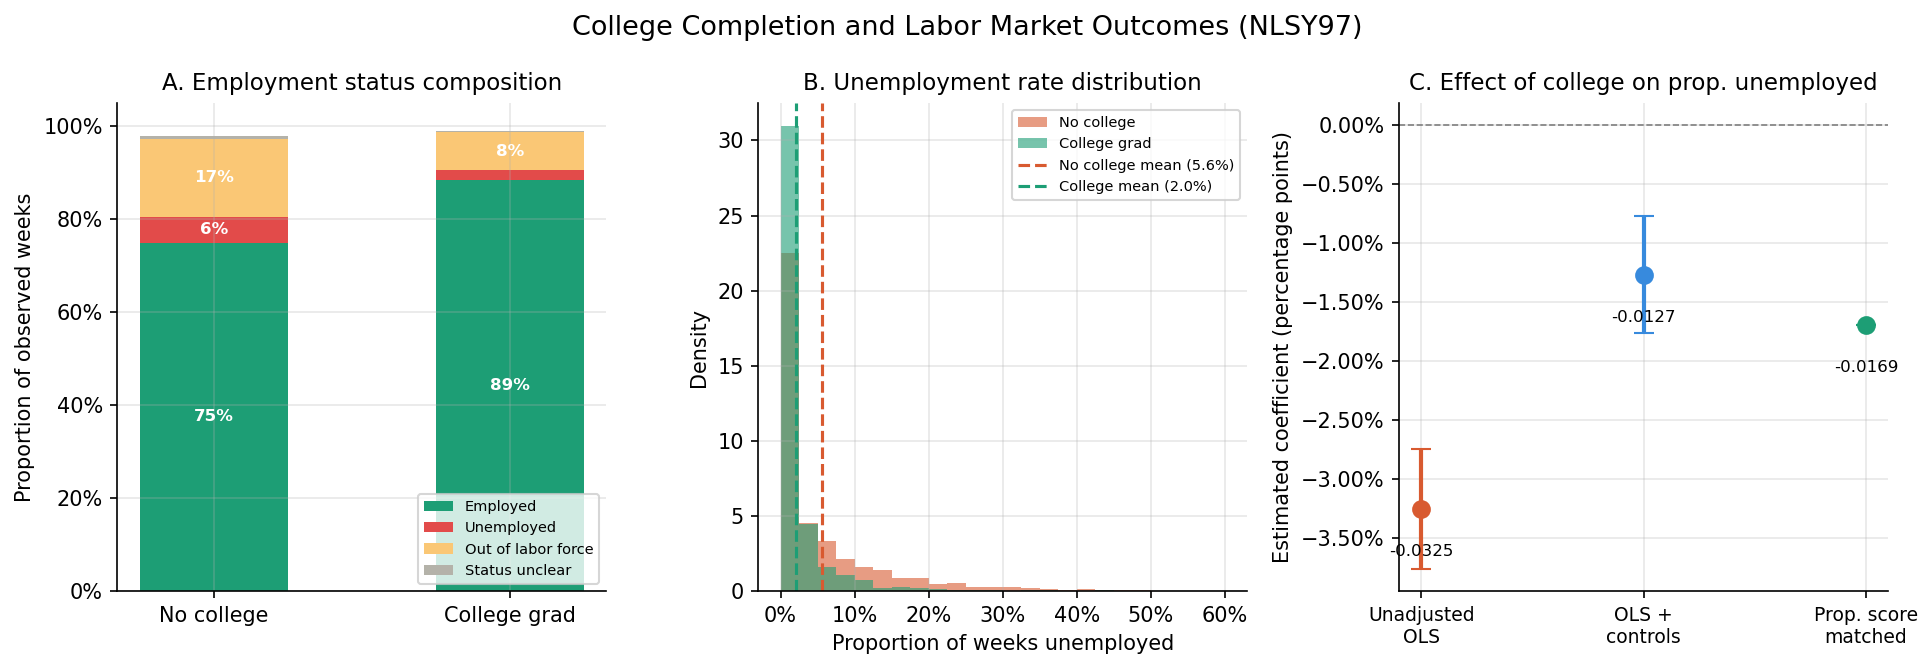

Figure 2 saved.


In [109]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — College & Employment (3-panel)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('College Completion and Labor Market Outcomes (NLSY97)', fontsize=13)

labels = ['No college', 'College grad']

# ── Panel A: Stacked employment status ──────────────────────────────────────
ax = axes[0]
emp_means = df.groupby('compcoll_age25')[[
    'prop_Employed','prop_Unemployed',
    'prop_Out of labor force','prop_Not working (unclear if unemployed or NILF)'
]].mean()

bottom = np.zeros(2)
cols_stack = ['#1D9E75','#E24B4A','#FAC775','#B4B2A9']
col_labels  = ['Employed','Unemployed','Out of labor force','Status unclear']
for col, clr, lbl in zip(emp_means.columns, cols_stack, col_labels):
    vals = emp_means[col].values
    ax.bar(labels, vals, bottom=bottom, color=clr, label=lbl, width=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(i, b + v/2, f'{v:.0%}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('A. Employment status composition')
ax.set_ylabel('Proportion of observed weeks')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='lower right', fontsize=7)
ax.set_ylim(0, 1.05)

# ── Panel B: Unemployment rate histogram ─────────────────────────────────────
ax = axes[1]
bins = np.linspace(0, 0.6, 25)
ax.hist(no_coll, bins=bins, density=True, alpha=0.6, color=CORAL, label='No college')
ax.hist(coll,    bins=bins, density=True, alpha=0.6, color=TEAL,  label='College grad')
ax.axvline(no_coll.mean(), color=CORAL, linestyle='--', linewidth=1.5,
           label=f'No college mean ({no_coll.mean():.1%})')
ax.axvline(coll.mean(),    color=TEAL,  linestyle='--', linewidth=1.5,
           label=f'College mean ({coll.mean():.1%})')
ax.set_title('B. Unemployment rate distribution')
ax.set_xlabel('Proportion of weeks unemployed')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=7)

# ── Panel C: Regression coefficients (unadjusted vs adjusted) ───────────────
ax = axes[2]
coef_raw = ols_raw.params['compcoll_age25']
ci_raw   = ols_raw.conf_int().loc['compcoll_age25'].values
coef_adj = ols_adj.params['compcoll_age25']
ci_adj   = ols_adj.conf_int().loc['compcoll_age25'].values
psm_est  = mean_t - mean_c

ests  = [coef_raw, coef_adj, psm_est]
cis   = [(coef_raw - ci_raw[0], ci_raw[1] - coef_raw),
         (coef_adj - ci_adj[0], ci_adj[1] - coef_adj),
         (0, 0)]
model_labels = ['Unadjusted\nOLS', 'OLS +\ncontrols', 'Prop. score\nmatched']
colors_est   = [CORAL, BLUE, TEAL]

for i, (est, ci, lbl, clr) in enumerate(zip(ests, cis, model_labels, colors_est)):
    ax.errorbar(i, est, yerr=[[ci[0]], [ci[1]]], fmt='o', color=clr,
                capsize=5, markersize=8, linewidth=2)
    ax.text(i, est - 0.003, f'{est:.4f}', ha='center', va='top', fontsize=8)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks(range(3))
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_title('C. Effect of college on prop. unemployed')
ax.set_ylabel('Estimated coefficient (percentage points)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('fig2_employment.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 2 saved.')

---
## 4. Supplementary Analyses

In [113]:
# ── Completion rates by sex × race ──────────────────────────────────────────
cross = df.groupby(['sex','race'])['compcoll_age25'].mean().unstack().round(3)
print('College completion rate by sex and race:')
print(cross)

College completion rate by sex and race:
race  Black  Hispanic  Mixed Race (Non-Hispanic)  Non-Black / Non-Hispanic
sex                                                                       
F     0.188     0.181                      0.237                     0.374
M     0.111     0.116                      0.324                     0.273


In [115]:
# ── Intact family × college completion ──────────────────────────────────────
chi2_stat, chi2_p, dof, _ = stats.chi2_contingency(
    pd.crosstab(df['intact'], df['compcoll_age25'])
)
print(f'Chi-squared test (intact family vs college): chi2={chi2_stat:.2f}, p={chi2_p:.2e}')
print(f'Intact family completion rate:    {df[df.intact==1]["compcoll_age25"].mean():.3f}')
print(f'Non-intact family completion rate: {df[df.intact==0]["compcoll_age25"].mean():.3f}')

Chi-squared test (intact family vs college): chi2=373.56, p=3.14e-83
Intact family completion rate:    0.357
Non-intact family completion rate: 0.153


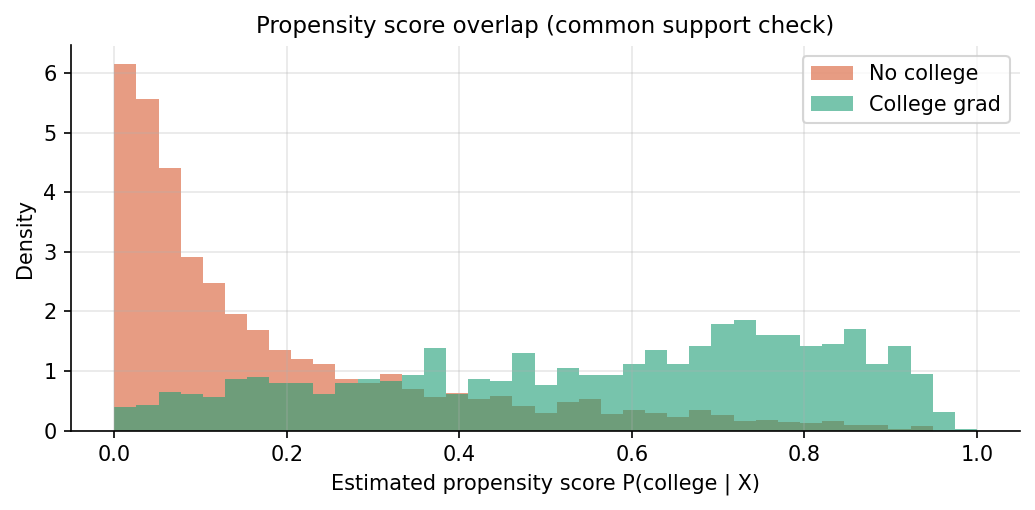

In [117]:
# ── Propensity score overlap (common support) ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
bins_ps = np.linspace(0, 1, 40)
ax.hist(df_ps[df_ps['compcoll_age25']==0]['ps'], bins=bins_ps,
        alpha=0.6, color=CORAL, density=True, label='No college')
ax.hist(df_ps[df_ps['compcoll_age25']==1]['ps'], bins=bins_ps,
        alpha=0.6, color=TEAL, density=True, label='College grad')
ax.set_xlabel('Estimated propensity score P(college | X)')
ax.set_ylabel('Density')
ax.set_title('Propensity score overlap (common support check)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_pscore_overlap.png', bbox_inches='tight', dpi=150)
plt.show()

In [119]:
# ── Covariate balance before/after PSM ──────────────────────────────────────
balance_vars = ['asvab_mv_pct','gpa','parinc','father_educ_years','delinq']

print('=== Standardized mean differences (before matching) ===')
for v in balance_vars:
    t_mean = df_ps[df_ps['compcoll_age25']==1][v].mean()
    c_mean = df_ps[df_ps['compcoll_age25']==0][v].mean()
    pooled_sd = np.sqrt((df_ps[df_ps['compcoll_age25']==1][v].var() +
                         df_ps[df_ps['compcoll_age25']==0][v].var()) / 2)
    smd = (t_mean - c_mean) / pooled_sd
    print(f'  {v:<25}: SMD = {smd:.3f}')

print('\n=== Standardized mean differences (after matching) ===')
for v in balance_vars:
    t_mean = matched[matched['compcoll_age25']==1][v].mean()
    c_mean = matched[matched['compcoll_age25']==0][v].mean()
    pooled_sd = np.sqrt((matched[matched['compcoll_age25']==1][v].var() +
                         matched[matched['compcoll_age25']==0][v].var()) / 2)
    smd = (t_mean - c_mean) / pooled_sd
    print(f'  {v:<25}: SMD = {smd:.3f}')

=== Standardized mean differences (before matching) ===
  asvab_mv_pct             : SMD = 1.153
  gpa                      : SMD = 1.138
  parinc                   : SMD = 0.627
  father_educ_years        : SMD = 0.791
  delinq                   : SMD = -0.482

=== Standardized mean differences (after matching) ===
  asvab_mv_pct             : SMD = 0.489
  gpa                      : SMD = 0.479
  parinc                   : SMD = 0.317
  father_educ_years        : SMD = 0.410
  delinq                   : SMD = -0.147


---
## 5. Summary of Key Findings

### Goal 1 — Predictors of college completion
- **Cognitive ability** (ASVAB, r = 0.45) and **academic performance** (HS GPA, r = 0.41; 8th grade grades, r = 0.40) are the strongest predictors.
- **Family socioeconomic background** matters: parental education (r ≈ 0.30–0.33) and income (Q4 vs Q1 gap: 44% vs 10%) independently predict completion.
- **Peer context**: students where >90% of peers planned college had a 34% completion rate vs 5% where almost none did.
- **Delinquency** (r = −0.17) and **family structure** (intact: 36% vs non-intact: 15%) also predict completion.
- Women outpaced men (28.4% vs 20.4%); Non-Black/Non-Hispanic respondents had higher rates than Black or Hispanic respondents (32% vs ~15%).

### Goal 2 — Effect on employment
- **Unadjusted**: College graduates had a 3.5 pp lower unemployment rate (2.0% vs 5.6%), highly significant (p ≈ 10⁻⁵⁶).
- **Adjusted OLS**: After controlling for ability, GPA, family background, and demographics, the estimated effect is attenuated (see Figure 2C), suggesting selection bias.
- **Propensity score matching**: After balancing covariates, the ATT estimate represents a cleaner causal estimate of college completion on unemployment.
- **Caution**: Remaining selection bias is likely. IV or natural experiments would be needed for a fully credible causal claim.
